# Hyperbolic MDS Analysis Notebook

This notebook provides a complete workflow for running Hyperbolic Multidimensional Scaling (HMDS). It loads a distance matrix from a `.mat` file, performs the embedding, and visualizes the results.

### 1. Import Libraries

First, we import the necessary functions from our helper script `analysis_from_mat.py`. Make sure you have restarted the kernel if you have recently modified this file.

In [412]:
import numpy as np
from analysis_from_mat import (
    load_dmat_from_mat, 
    run_embedding,
    run_euclidean_embedding,
    plot_shepard_diagram, 
    visualize_embedding,
    outlier_sensitivity_analysis,
    corr_to_distance,
    corr_unc_to_dist_unc,
    surrogate_distance_matrix
)

print("Modules imported successfully!")

Modules imported successfully!


### 2. Set Analysis Parameters

Define the path to your data file, the name of the distance matrix variable within that file, and the desired embedding dimension.

In [ ]:
import os
import pickle

# --- Main Analysis Parameters ---
mat_file_path = 'data/distance_matrix_fish1.mat'      # <-- UPDATE THIS PATH
matrix_variable_name = 'distance_laserOn' # <-- UPDATE THIS VARIABLE NAME
#uncertainty_variable_name = None # <-- UPDATE THIS, variance of distance matrix or set to None if not applicable
uncertainty_variable_name = 'var_dij_laserOn'
embedding_dim = 6

# --- Caching Parameters ---
# Set to True to force re-running the embedding even if a saved file exists.
force_rerun = True
# Path to save/load the embedding results.
context = f'laserOn(d=6)fish1'
#context = f'laserOn(d=6)fish4_nounc'
results_path = f'results/fit_results_{context}.pkl'

### 3. Load Data

Use the `load_dmat_from_mat` function to load your distance matrix. This function can handle both old and new (`v7.3`) MATLAB file formats.

In [414]:
try:
    distance_matrix = load_dmat_from_mat(mat_file_path, matrix_variable_name)
    #it is computed using the linear method (cosine similarity 1 - Cij)
except Exception as e:
    print(f"An error occurred: {e}")

corr_mat = 1 - distance_matrix
corr_mat = (corr_mat + corr_mat.T) / 2.0
dmat_chord = corr_to_distance(corr_mat, method='chord')

uncertainty_matrix = None
if uncertainty_variable_name:
    print(f"Loading uncertainty matrix '{uncertainty_variable_name}' from: {mat_file_path}")
    uncertainty_matrix = load_dmat_from_mat(mat_file_path, uncertainty_variable_name)
    dmat_unc = corr_unc_to_dist_unc(corr_mat, uncertainty_matrix, method='chord', reg = 0.01)
else:
    dmat_unc = None


#distance_matrix, indices = sample_submatrix(distance_matrix, n=600, seed=42)
#uncertainty_matrix = uncertainty_matrix[np.ix_(indices, indices)]

Detected MATLAB v7.3 file, switching to h5py reader...
Successfully loaded matrix 'distance_laserOn' with shape: (611, 611)
Loading uncertainty matrix 'var_dij_laserOn' from: data/distance_matrix_fish1.mat
Detected MATLAB v7.3 file, switching to h5py reader...
Successfully loaded matrix 'var_dij_laserOn' with shape: (611, 611)


### 4. Run the Embedding

Pass the loaded distance matrix to the `run_embedding` function. This will normalize the data, perform the optimization, and return a dictionary with all the results. This step may take several minutes, but the noisy compiler/optimizer output is suppressed.

In [415]:
if not force_rerun and os.path.exists(results_path):
    print(f"Loading existing embedding results from: {results_path}")
    with open(results_path, 'rb') as f_in:
        fit_results = pickle.load(f_in)
else:
    print("No saved results found or rerun is forced. Running embedding...")
    fit_results = run_embedding(dmat_chord, embedding_dim, dmat_unc=dmat_unc, output_path=results_path)
    print("\nEmbedding finished.")

Loading existing embedding results from: results/fit_results_laserOn(d=6)fish1.pkl


### 5. Inspect the Results

The `fit_results` dictionary contains all the output from the embedding. You can inspect its keys and values to access the coordinates, curvature, etc.

In [416]:
# Print the keys to see what's available
print("Available keys in fit_results:", list(fit_results.keys()))

# Access the centered Poincare coordinates
poincare_coords = fit_results['cp']
print(f"\nShape of Poincare coordinates: {poincare_coords.shape}")

Available keys in fit_results: ['euc', 'sig', 'lambda', 'time', 'dmat', 'poin', 'rs', 'emb_mat', 'cp', 'crs', 'bic']

Shape of Poincare coordinates: (611, 6)


### 6. Plot Shepard Diagram

Create the Shepard diagram to visually assess the quality of the embedding. This compares the original distances to the distances in the new hyperbolic space.

Generating Shepard diagram...
Sampling 37271 of 186355 pairs for Shepard diagram (20.0%).


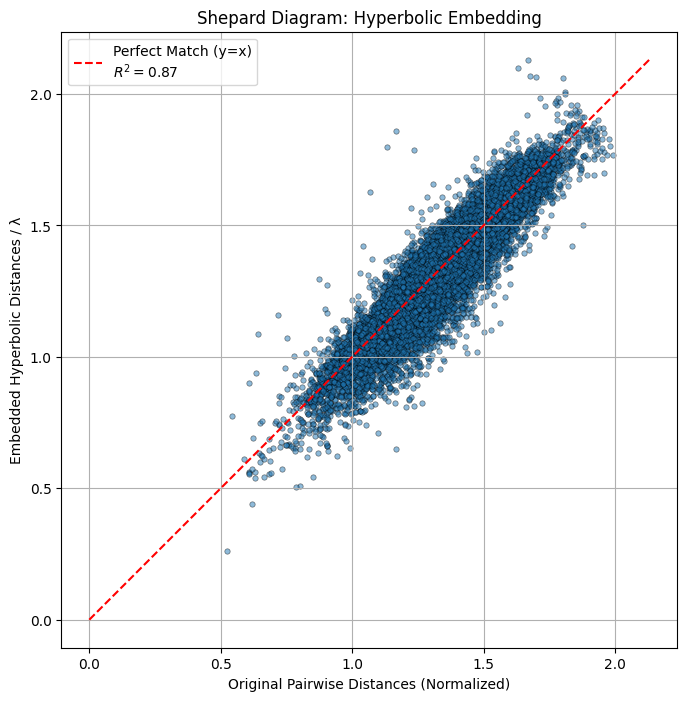

Saving Shepard diagram to Figure/Shepard_Diagram_laserOn(d=6)fish1_hyperbolic.pdf...
curvature λ: 5.100329907431257
Hyperbolic Embedding BIC: -261052.39


In [417]:
if 'fit_results' in locals():
    plot_shepard_diagram(fit_results['dmat'], fit_results['emb_mat'], fit_results['lambda'], title="Shepard Diagram: Hyperbolic Embedding", output_file=f'Figure/Shepard_Diagram_{context}_hyperbolic.pdf', sample_fraction=0.2)
    print(f"curvature λ: {fit_results['lambda']}")
    print(f"Hyperbolic Embedding BIC: {fit_results['bic']:.2f}")

In [418]:
euclidean_results = run_euclidean_embedding(dmat_chord, embedding_dim)


Starting Euclidean MDS embedding into 6 dimensions...


/Users/quanwen/Documents/GitHub/BayesianHMDS/hmds_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/quanwen/Documents/GitHub/BayesianHMDS/hmds_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/quanwen/Documents/GitHub/BayesianHMDS/hmds_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/quanwen/Documents/GitHub/BayesianHMDS/hmds_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/quanwen/Documents/GitHub/BayesianHMDS/hmds_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/quanwen/Documents/GitHub/BayesianHMDS/hmds_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: Runtim

Generating Shepard diagram...
Sampling 37271 of 186355 pairs for Shepard diagram (20.0%).


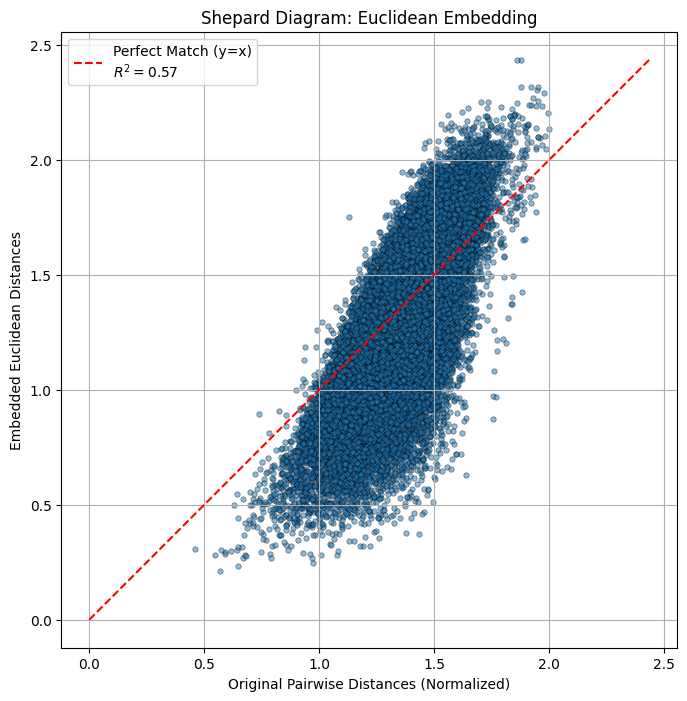

Saving Shepard diagram to Figure/Shepard_Diagram_laserOn(d=6)fish1_euclidean.pdf...
Euclidean Embedding BIC: 30223.70


In [419]:
if 'euclidean_results' in locals():
    plot_shepard_diagram(euclidean_results['dmat'], euclidean_results['emb_mat'],
                                 title="Shepard Diagram: Euclidean Embedding", output_file=f'Figure/Shepard_Diagram_{context}_euclidean.pdf', sample_fraction=0.2)
    print(f"Euclidean Embedding BIC: {euclidean_results['bic']:.2f}")

### 7. Visualize Embedding Space

Finally, visualize the embedded points themselves. 
- If `d=2` or `d=3`, the points are plotted directly.
- If `d > 3`, we use PCA to find the 2D projection that captures the most variance and plot that instead.

In [420]:
if 'fit_results' in locals():
    visualize_embedding(fit_results, output_prefix=f'Figure/Poincare_circle_{context}')


Embedding dimension is 6 (>3). Projecting to 2D using PCA for visualization.
The 3D PCA projection explains 60.48% of the variance.
Generating interactive 3D Poincare ball visualization...
Saving 3D plot to Figure/Poincare_circle_laserOn(d=6)fish1_pca_3d.pdf...
Generating 2D projections of the 3D embedding...
Saving 3D projections plot to Figure/Poincare_circle_laserOn(d=6)fish1_pca_3d_projections.pdf...


/Users/quanwen/Documents/GitHub/BayesianHMDS/hmds_env/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/quanwen/Documents/GitHub/BayesianHMDS/hmds_env/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/quanwen/Documents/GitHub/BayesianHMDS/hmds_env/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


results = outlier_sensitivity_analysis(
      dmat_chord,
      embedding_dim=embedding_dim,
      removal_fractions=(0.05, 0.10, 0.20),  # cumulative removals
      dmat_unc=dmat_unc,
      verbose=False,
  )

surrogate_results = surrogate_distance_matrix(corr_mat, seed=42)
fit_surrogate  = run_embedding(surrogate_results['dmat_surrogate'], embedding_dim=embedding_dim) 